In [ ]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [ ]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__  #('2.2.1+cu121', '2.2.2')

('2.8.0+cu126', '2.5.5')

## WnB install

In [ ]:
!pip install wandb -qU
import wandb
wandb.login()   # 실행하면 API 키 입력창이 뜬다 (키를 코드에 적지 않는다)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gshong (PT2505) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## MLP, CNN 모델 학습에 W&B적용해 보기

In [ ]:
from torchvision.datasets import MNIST

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size = 512
download_root = ''
train_dataset = MNIST(download_root, train=True, download=True, transform=transform)
test_dataset = MNIST(download_root, train=False, download=True, transform=transform)
trainDataLoader = DataLoader(train_dataset, batch_size, True,num_workers=4)
valDataLoader = DataLoader(test_dataset, batch_size, False,num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.76MB/s]


[] Shapetorch.Size([60000, 28, 28]), <class 'torch.Tensor'>
[] Shapetorch.Size([60000]), <class 'torch.Tensor'>


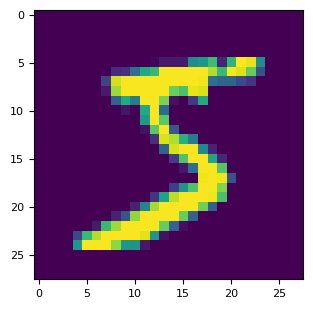

In [ ]:
pst(trainDataLoader.dataset.data)    # image
pst(trainDataLoader.dataset.targets) # label
plt.imshow(trainDataLoader.dataset.data[0])
plt.show()

In [ ]:
batch_n = len(trainDataLoader.dataset.data) // batch_size
batch_n

117

In [ ]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

### MLP Model

In [ ]:
# MLP model
class MLP(Wrap_10):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(  # Container
            nn.Flatten(),
            nn.Linear(28*28, 384),
            nn.ReLU(),
            nn.Linear(384, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

mlp = MLP()
summary(mlp, input_size=(batch_size, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [512, 10]                 --
├─Sequential: 1-1                        [512, 10]                 --
│    └─Flatten: 2-1                      [512, 784]                --
│    └─Linear: 2-2                       [512, 384]                301,440
│    └─ReLU: 2-3                         [512, 384]                --
│    └─Linear: 2-4                       [512, 10]                 3,850
Total params: 305,290
Trainable params: 305,290
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 156.31
Input size (MB): 1.61
Forward/backward pass size (MB): 1.61
Params size (MB): 1.22
Estimated Total Size (MB): 4.44

### WandB Logger

In [ ]:
from lightning.pytorch.loggers import WandbLogger

In [ ]:
%%time
model = MLP()

epochs = 10
name="mlp"
## log_model:'best', best모델을 w&b에 저장, ModelCheckpoint가 따라와야 함
logger = WandbLogger(entity="PT2505",project="ConvNet_wnb", name=name, log_model="best")

## log gradients, parameter histogram
logger.watch(model,log="all",log_freq=100)

checkpoint_callback = ModelCheckpoint( monitor="val_acc",mode="max",#save_top_k=1,
                        dirpath="./checkpoints", filename="best_model")

trainer = Trainer(max_epochs=epochs, logger=logger,
                  callbacks=[checkpoint_callback],
                  enable_model_summary=False)
trainer.fit(model, trainDataLoader, valDataLoader)

trainer.validate(model, dataloaders=valDataLoader)

# 학습 후 수동 업로드 # Free acount는 자동저장되지 않음
wandb.save("./checkpoints/best_model.ckpt")

wandb.finish() ###

wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | '

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9758999943733215     │
│         val_loss          │    0.07855413854122162    │
└───────────────────────────┴───────────────────────────┘

acc,▁▅▆▇▇▇████
epoch,▁▁▂▂▂▂▃▃▄▄▅▅▅▅▆▆▇▇▇▇█
loss,█▄▃▂▂▂▁▁▁▁
trainer/global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇███
val_acc,▁▄▅▆▇▇▇████
val_loss,█▅▄▃▂▂▁▁▁▁▁
acc,0.98745
epoch,10
loss,0.04716
trainer/global_step,1180
val_acc,0.9759


CPU times: user 12.4 s, sys: 3.98 s, total: 16.4 s
Wall time: 48.9 s


Wall time: 55.7 s

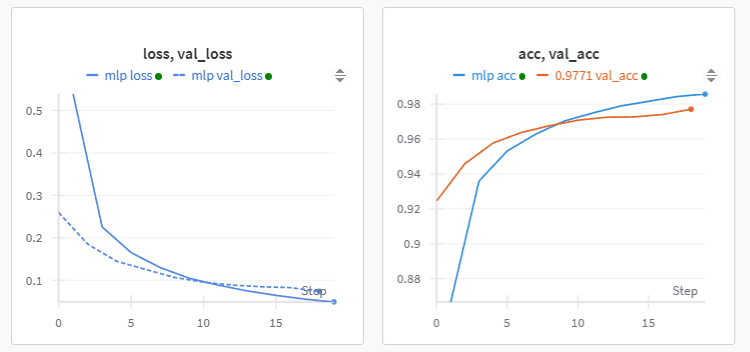

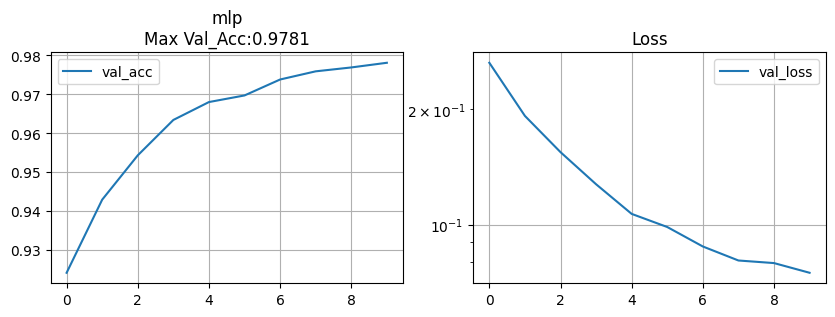

### W&B에 저장된 model down load 하기   
#### 또는, run page > files > checkpoints에서 file 직접 download 가능  

In [ ]:
import wandb

api = wandb.Api()

# 프로젝트, 실험 이름, run ID를 정확히 입력
run_id = "fmqpv62y" ## run 선택하고, URL에서 확인 가능 ##
run = api.run(f"PT2505/ConvNet_wnb/{run_id}")

# 파일 목록 확인
files = run.files()
for f in files:
    print(f.name)

# 원하는 파일 다운로드
ckpt_path = "checkpoints/best_model.ckpt"
f = run.file(ckpt_path)
f.download(replace=True)
wandb.finish()

model = MLP.load_from_checkpoint(ckpt_path)

trainer = Trainer()
trainer.validate(model, dataloaders=valDataLoader)

artifact/1801539995/wandb_manifest.json
checkpoints/best_model.ckpt
config.yaml
media/graph/graph_0_summary_17d1cf1752512d44758b.graph.json
output.log
requirements.txt
wandb-metadata.json
wandb-summary.json


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9764000177383423     │
│         val_loss          │    0.07757684588432312    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.07757684588432312, 'val_acc': 0.9764000177383423}]

## 실습과제 : CNN 모델 학습에 WandB를 적용해보자   
### 1) gradients, parameter histogram을 확인해 보자   
### 2) ModelCheckpoint를 사용하여 best 모델을 WandB에 저장하고, 다시 load하여 성능을 확인하자
### 3) W&B에서 mlp,cnn 학습결과를 비교해 보자    


### CNN Model

In [ ]:
## Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=0) ##
print(nn.Conv2d(3, 16, (3, 3), stride=(1,1), padding=(1,1)))
print(nn.Conv2d(3, 16, 3, stride=1, padding=1))
print(nn.Conv2d(3, 16, 3, padding='same'))
print(nn.Conv2d(3, 16, 3))

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))


In [ ]:
class CNN(Wrap_10):
    def __init__(self):
        super(CNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, (3, 3), stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 32, (3, 3), stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*6*6, 10) )

    def forward(self, x):
        out = self.layers(x)
        return out

cnn = CNN()
summary(cnn, input_size=(batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [512, 10]                 --
├─Sequential: 1-1                        [512, 10]                 --
│    └─Conv2d: 2-1                       [512, 32, 13, 13]         320
│    └─ReLU: 2-2                         [512, 32, 13, 13]         --
│    └─Conv2d: 2-3                       [512, 32, 6, 6]           9,248
│    └─ReLU: 2-4                         [512, 32, 6, 6]           --
│    └─Flatten: 2-5                      [512, 1152]               --
│    └─Linear: 2-6                       [512, 10]                 11,530
Total params: 21,098
Trainable params: 21,098
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 204.05
Input size (MB): 1.61
Forward/backward pass size (MB): 26.91
Params size (MB): 0.08
Estimated Total Size (MB): 28.60

In [ ]:
%%time
model = CNN()

name="cnn"
logger = WandbLogger(entity="PT2505",project="ConvNet_wnb", name=name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, valDataLoader)
wandb.finish() ###

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


acc,▁▅▇▇▇█████
epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
loss,█▃▂▂▁▁▁▁▁▁
trainer/global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
val_acc,▁▄▆▇▇▇████
val_loss,█▅▃▂▂▂▁▁▁▁
acc,0.98365
epoch,9
loss,0.05567
trainer/global_step,1179
val_acc,0.9827


CPU times: user 11.1 s, sys: 3.49 s, total: 14.6 s
Wall time: 48 s


Wall time: 43.2 s

### 아래와 같이 mlp,cnn 학습결과를 비교해 보자

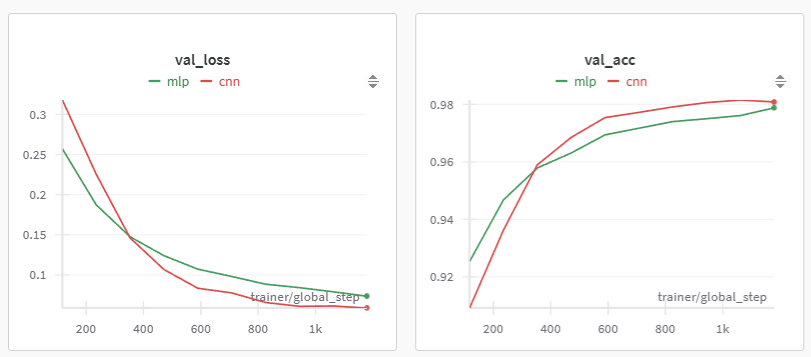